In [2]:
# ============================================================
# Phase 2: Fine-tuning pretrained CNNs on a fine-grained dataset.
# Setup: imports, paths, reproducibility, device.
# ============================================================

import os
import json
import time
import random
from pathlib import Path
from copy import deepcopy
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights, vgg16, VGG16_Weights
import matplotlib.pyplot as plt
from PIL import Image

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Paths ---
PROJECT_ROOT = Path("/content/drive/MyDrive/comp8430_project")
DATA_DIR     = PROJECT_ROOT / "data" / "resized_256"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
FIG_DIR      = OUTPUT_DIR / "figures_phase2"
MODEL_DIR    = OUTPUT_DIR / "models_phase2"
LOG_DIR      = OUTPUT_DIR / "logs"
SPLITS_FILE  = LOG_DIR / "splits.json"            # reuses Phase 1-2 splits

for d in [FIG_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Data dir not found: {DATA_DIR}"
assert SPLITS_FILE.exists(), (
    f"Splits file not found at {SPLITS_FILE}.")

print(f"PyTorch:      {torch.__version__}")
print(f"Torchvision:  {torchvision.__version__}")
print(f"Device:       {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
print(f"Data dir:     {DATA_DIR}")
print(f"Splits file:  {SPLITS_FILE}")

Mounted at /content/drive
PyTorch:      2.11.0+cu128
Torchvision:  0.26.0+cu128
Device:       cuda
GPU:          NVIDIA L4
Data dir:     /content/drive/MyDrive/comp8430_project/data/resized_256
Splits file:  /content/drive/MyDrive/comp8430_project/outputs/logs/splits.json


In [ ]:
# ============================================================
# Datasets and transforms.
# Two training pipelines: tf_mild (Phase 1-2 style) and
# tf_strong (heavier augmentation for the augmentation ablation).
# Eval transform unchanged from Phase 1-2 so test scores are
# directly comparable across both phases.
# ============================================================

# ImageNet normalisation (required by both pretrained backbones)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# --- Mild augmentation: same as Phase 1-2 ---
tf_mild = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Strong augmentation: RandAugment + stronger jitter + erasing ---
# Note: RandomErasing is applied AFTER normalisation per torchvision convention.
tf_strong = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),     # mixes rotation/shear/etc
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

# --- Eval transform: deterministic, identical to Phase 1-2 ---
tf_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

# --- Dataset class (same as Phase 1-2) ---
class CansDataset(Dataset):
    def __init__(self, data_dir, split_entries, class_to_idx, transform):
        self.data_dir = Path(data_dir)
        self.entries = split_entries
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        rel_path, cname = self.entries[idx]
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        img = self.transform(img)
        label = self.class_to_idx[cname]
        return img, label

# --- Load splits and build the class index ---
with open(SPLITS_FILE) as f:
    split_doc = json.load(f)

class_names_in_splits = sorted({entry[1] for split in split_doc["splits"].values()
                                          for entry in split})
CLASS_NAMES  = class_names_in_splits
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASS_NAMES)

# --- Two training datasets (one per augmentation), one val, one test ---
train_ds_mild   = CansDataset(DATA_DIR, split_doc["splits"]["train"], CLASS_TO_IDX, tf_mild)
train_ds_strong = CansDataset(DATA_DIR, split_doc["splits"]["train"], CLASS_TO_IDX, tf_strong)
val_ds          = CansDataset(DATA_DIR, split_doc["splits"]["val"],   CLASS_TO_IDX, tf_eval)
test_ds         = CansDataset(DATA_DIR, split_doc["splits"]["test"],  CLASS_TO_IDX, tf_eval)

# --- DataLoaders ---
BATCH_SIZE  = 32
NUM_WORKERS = 2

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

train_loader_mild   = make_loader(train_ds_mild,   shuffle=True)
train_loader_strong = make_loader(train_ds_strong, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train (mild aug):    {len(train_ds_mild):4d}  ({len(train_loader_mild)} batches)")
print(f"Train (strong aug):  {len(train_ds_strong):4d}  ({len(train_loader_strong)} batches)")
print(f"Val:                 {len(val_ds):4d}  ({len(val_loader)} batches)")
print(f"Test:                {len(test_ds):4d}  ({len(test_loader)} batches)")

Classes (5): ['monster__ultra_blue_hawaiian', 'monster__ultra_fiesta', 'monster__ultra_strawberry_dreams', 'monster__zero_sugar', 'monster__zero_ultra']
Train (mild aug):     287  (9 batches)
Train (strong aug):   287  (9 batches)
Val:                   47  (2 batches)
Test:                 145  (5 batches)


In [3]:
# ============================================================
# Model builder for Phase 2.
#
# Three strategies, controlled by the `strategy` argument:
#   "frozen":      backbone frozen, only the new head trains.
#                  Same as Phase 1-2; serves as the R0 baseline.
#   "last_block":  freeze early layers, unfreeze only the LAST
#                  conv block and the new head. A common middle
#                  ground that lets the model adapt high-level
#                  features to the new domain without over-
#                  fitting the (data-hungry) early layers.
#   "full":        all layers trainable. Combined with
#                  discriminative learning rates: early layers
#                  get a small LR (they should change little),
#                  late layers and head get a larger LR.
#
# Returns (model, param_groups, info), where param_groups is a
# list of dicts ready to be passed to an optimizer with
# per-group learning rates.
# ============================================================

def _set_requires_grad(module: nn.Module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def build_model_phase2(name: str, num_classes: int, strategy: str,
                      head_lr: float = 1e-3, backbone_lr: float = 1e-4):
    """Build a pretrained model with a fresh head and chosen freeze strategy.

    For each strategy, returns parameter groups with the right LRs.
    """
    name = name.lower()

    if name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_module = model.fc

        # ResNet-50's "last block" is `layer4`; everything before it is the early backbone.
        # Module structure: conv1 -> bn1 -> relu -> maxpool -> layer1 -> layer2 -> layer3 -> layer4 -> avgpool -> fc
        early_modules = [model.conv1, model.bn1, model.layer1, model.layer2, model.layer3]
        late_modules  = [model.layer4]

    elif name == "vgg16":
        weights = VGG16_Weights.IMAGENET1K_V1
        model = vgg16(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        head_module = model.classifier[-1]

        # VGG-16 features have 5 conv "blocks" separated by maxpools.
        # `features` is a Sequential of 31 layers; the last conv block starts at index 24 (conv5_1).
        early_modules = [model.features[:24], model.classifier[:-1]]   # all conv blocks 1-4 + FC1, FC2
        late_modules  = [model.features[24:]]                          # conv5_1, conv5_2, conv5_3, pool

    else:
        raise ValueError(f"Unknown model: {name}")

    # Apply the freezing strategy
    if strategy == "frozen":
        for m in early_modules + late_modules:
            _set_requires_grad(m, False)
        _set_requires_grad(head_module, True)
        param_groups = [{"params": head_module.parameters(), "lr": head_lr}]

    elif strategy == "last_block":
        for m in early_modules:
            _set_requires_grad(m, False)
        for m in late_modules:
            _set_requires_grad(m, True)
        _set_requires_grad(head_module, True)
        param_groups = [
            {"params": [p for m in late_modules for p in m.parameters()], "lr": backbone_lr},
            {"params": head_module.parameters(),                          "lr": head_lr},
        ]

    elif strategy == "full":
        for m in early_modules + late_modules:
            _set_requires_grad(m, True)
        _set_requires_grad(head_module, True)
        # Discriminative LRs: early layers train slowly, late layers faster, head fastest.
        param_groups = [
            {"params": [p for m in early_modules for p in m.parameters()], "lr": backbone_lr * 0.1},
            {"params": [p for m in late_modules  for p in m.parameters()], "lr": backbone_lr},
            {"params": head_module.parameters(),                           "lr": head_lr},
        ]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Sanity / reporting
    n_total     = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    info = {
        "name": name,
        "strategy": strategy,
        "params_total": n_total,
        "params_trainable": n_trainable,
        "trainable_fraction": n_trainable / n_total,
        "num_param_groups": len(param_groups),
        "lrs": [g["lr"] for g in param_groups],
    }
    return model.to(DEVICE), param_groups, info

In [ ]:
# --- Verify all 6 combinations build correctly and print summary ---
print(f"{'Model':<10s} {'Strategy':<12s} {'Total':>10s} {'Trainable':>12s} {'Frac':>7s} {'LRs':>30s}")
print("-" * 92)
for name in ["resnet50", "vgg16"]:
    for strategy in ["frozen", "last_block", "full"]:
        m, _, info = build_model_phase2(name, NUM_CLASSES, strategy)
        lrs_str = "[" + ", ".join(f"{lr:.0e}" for lr in info["lrs"]) + "]"
        print(f"{info['name']:<10s} {info['strategy']:<12s} "
              f"{info['params_total']/1e6:>8.2f}M  "
              f"{info['params_trainable']/1e6:>9.3f}M  "
              f"{info['trainable_fraction']*100:>6.2f}% "
              f"{lrs_str:>30s}")
        del m
torch.cuda.empty_cache()

Model      Strategy          Total    Trainable    Frac                            LRs
--------------------------------------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


resnet50   frozen          23.52M      0.010M    0.04%                        [1e-03]
resnet50   last_block      23.52M     14.975M   63.67%                 [1e-04, 1e-03]
resnet50   full            23.52M     23.518M  100.00%          [1e-05, 1e-04, 1e-03]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 230MB/s]


vgg16      frozen         134.28M      0.020M    0.02%                        [1e-03]
vgg16      last_block     134.28M      7.100M    5.29%                 [1e-04, 1e-03]
vgg16      full           134.28M    134.281M  100.00%          [1e-05, 1e-04, 1e-03]


In [ ]:
# ============================================================
# Training utilities for Phase 2.
# Extensions over Phase 1-2:
#   - Optimizer accepts pre-built parameter groups (one LR per group).
#   - Optional learning-rate scheduler (constant or cosine annealing).
#   - Returns full LR history per epoch (useful for plotting).
# Otherwise: same per-image loss averaging, same best-on-val
# checkpoint selection, same eval logic.
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scheduler=None):
    """One pass over the training set. Returns (loss, acc, current_lrs)."""
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)
    # Step scheduler ONCE per epoch, after the optimizer steps.
    # For per-batch schedulers we'd step inside the inner loop; cosine annealing
    # over epochs is what we want here, so per-epoch is correct.
    if scheduler is not None:
        scheduler.step()
    current_lrs = [g["lr"] for g in optimizer.param_groups]
    return running_loss / total, correct / total, current_lrs


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


def run_finetuning(
    model_name: str,
    strategy: str,
    train_loader,
    *,
    num_epochs: int = 12,
    head_lr: float = 1e-3,
    backbone_lr: float = 1e-4,
    schedule: str = "constant",     # "constant" or "cosine"
    weight_decay: float = 1e-4,
    run_id: str = "run",
    verbose: bool = True,
):
    """Build, train, and return a fine-tuned model + history.

    Args:
        model_name:   "resnet50" or "vgg16"
        strategy:     "frozen", "last_block", "full" (see build_model_phase2)
        train_loader: which of the augmentation-specific loaders to use
        schedule:     "constant" -> no LR scheduler; "cosine" -> CosineAnnealingLR
        run_id:       short string used in printed headers and checkpoint filenames
    """
    model, param_groups, info = build_model_phase2(
        model_name, NUM_CLASSES, strategy,
        head_lr=head_lr, backbone_lr=backbone_lr)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(param_groups, weight_decay=weight_decay)

    if schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs, eta_min=1e-7)
    elif schedule == "constant":
        scheduler = None
    else:
        raise ValueError(f"Unknown schedule: {schedule}")

    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "lrs": []}
    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    if verbose:
        print(f"\n=== {run_id} | {model_name} | strategy={strategy} | "
              f"schedule={schedule} | epochs={num_epochs} ===")
        lr_header = "lrs"
        print(f"{'Ep':>3s} {'tr_loss':>8s} {'tr_acc':>7s} "
              f"{'va_loss':>8s} {'va_acc':>7s} {'time':>6s} {lr_header}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc, current_lrs = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lrs"].append(current_lrs)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            star = "*"
        else:
            star = " "

        if verbose:
            lrs_fmt = "[" + ", ".join(f"{lr:.0e}" for lr in current_lrs) + "]"
            print(f"{epoch:>3d} {tr_loss:>8.4f} {tr_acc:>7.4f} "
                  f"{va_loss:>8.4f} {va_acc:>7.4f} {dt:>5.1f}s {star} {lrs_fmt}")

    # Restore best-on-val weights
    model.load_state_dict(best_state)
    if verbose:
        print(f"  best val_acc = {best_val_acc:.4f} at epoch {best_epoch}")

    # Persist checkpoint (full state + metadata so it's self-describing)
    ckpt_path = MODEL_DIR / f"{run_id}.pt"
    torch.save({
        "run_id": run_id,
        "model_name": model_name,
        "strategy": strategy,
        "schedule": schedule,
        "state_dict": best_state,
        "class_to_idx": CLASS_TO_IDX,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history,
        "info": info,
    }, ckpt_path)
    if verbose:
        print(f"  saved: {ckpt_path.name}")

    return model, history, info

### Fine Tuning for Monsters
Fine tuning VGG16 and ResNet50 models with the photos taken of Monster Drinks to compare them with previous phase results.

In [ ]:
# ============================================================
# The 10-run ablation grid.
#
#  R0  frozen      | const  | mild   — Phase 1-2 baseline replication
#  R1  last_block  | const  | mild   — Does unfreezing help with no other change?
#  R2  last_block  | cosine | mild   — Does the LR schedule help?
#  R3  last_block  | cosine | strong — Does stronger augmentation help?
#  R4  full        | cosine | strong — Does full fine-tuning beat partial?
#
# All 5 runs are done for each of ResNet-50 and VGG-16.
# Each run trains its own model and stores history + best-val checkpoint.
# ============================================================

GRID = [
    # (run_suffix, strategy,     schedule, aug)
    ("R0_frozen_const_mild",      "frozen",     "constant", "mild"),
    ("R1_last_const_mild",        "last_block", "constant", "mild"),
    ("R2_last_cosine_mild",       "last_block", "cosine",   "mild"),
    ("R3_last_cosine_strong",     "last_block", "cosine",   "strong"),
    ("R4_full_cosine_strong",     "full",       "cosine",   "strong"),
]

EPOCHS = 12

phase2_results = {}   # phase2_results[run_id] = {"model": ..., "history": ..., "info": ..., "config": ...}

t_grid_start = time.time()
for arch in ["resnet50", "vgg16"]:
    for suffix, strategy, schedule, aug in GRID:
        run_id = f"{arch}_{suffix}"
        loader = train_loader_strong if aug == "strong" else train_loader_mild

        model, history, info = run_finetuning(
            model_name=arch,
            strategy=strategy,
            train_loader=loader,
            num_epochs=EPOCHS,
            head_lr=1e-3,
            backbone_lr=1e-4,
            schedule=schedule,
            weight_decay=1e-4,
            run_id=run_id,
            verbose=True,
        )
        phase2_results[run_id] = {
            "model": model,
            "history": history,
            "info": info,
            "config": {"arch": arch, "strategy": strategy,
                       "schedule": schedule, "aug": aug},
        }
        # free GPU memory before the next run
        torch.cuda.empty_cache()

print(f"\n=== Grid complete in {(time.time()-t_grid_start)/60:.1f} min ===")
print(f"Trained {len(phase2_results)} models, saved to {MODEL_DIR}")


=== resnet50_R0_frozen_const_mild | resnet50 | strategy=frozen | schedule=constant | epochs=12 ===
 Ep  tr_loss  tr_acc  va_loss  va_acc   time lrs
  1   1.5300  0.3240   1.3760  0.6596 142.0s * [1e-03]
  2   1.2649  0.6829   1.1723  0.7234   2.2s * [1e-03]
  3   1.0985  0.8084   1.0279  0.7872   2.2s * [1e-03]
  4   0.9562  0.8537   0.9046  0.8511   2.2s * [1e-03]
  5   0.8202  0.8955   0.7981  0.8936   2.2s * [1e-03]
  6   0.7004  0.9303   0.7267  0.8936   2.6s   [1e-03]
  7   0.6478  0.9373   0.6728  0.9149   2.7s * [1e-03]
  8   0.5889  0.9199   0.6073  0.9362   2.2s * [1e-03]
  9   0.5400  0.9477   0.5541  0.9149   2.1s   [1e-03]
 10   0.4924  0.9547   0.5350  0.8936   2.2s   [1e-03]
 11   0.4817  0.9582   0.5065  0.9149   2.2s   [1e-03]
 12   0.4126  0.9652   0.4634  0.9362   2.2s   [1e-03]
  best val_acc = 0.9362 at epoch 8
  saved: resnet50_R0_frozen_const_mild.pt

=== resnet50_R1_last_const_mild | resnet50 | strategy=last_block | schedule=constant | epochs=12 ===
 Ep  tr_loss

In [ ]:

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs))

def per_class_accuracy(labels, preds, num_classes):
    accs = np.zeros(num_classes)
    for c in range(num_classes):
        mask = labels == c
        accs[c] = (preds[mask] == c).sum() / max(mask.sum(), 1)
    return accs

def macro_f1(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(labels, preds): cm[t, p] += 1
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    p = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 0.0)
    r = np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1), 0.0)
    f1 = np.where(p + r > 0, 2 * p * r / np.maximum(p + r, 1e-12), 0.0)
    return f1.mean()

In [ ]:
# ============================================================
# Test-set evaluation for every run in the ablation grid.
# Identical evaluation protocol to Phase 1-2 (same test_loader,
# same eval transform, same metrics) so Phase 1-2 baselines are
# directly comparable.
# ============================================================

# --- Evaluate every run, store predictions and metrics ---
test_results = {}
for run_id, r in phase2_results.items():
    labels, preds, probs = predict_all(r["model"], test_loader)
    acc = (labels == preds).mean()
    test_loss = -np.log(np.clip(probs[np.arange(len(labels)), labels], 1e-12, 1.0)).mean()
    per_class = per_class_accuracy(labels, preds, NUM_CLASSES)
    m_f1 = macro_f1(labels, preds, NUM_CLASSES)
    best_val = max(r["history"]["val_acc"])
    test_results[run_id] = {
        "labels": labels, "preds": preds, "probs": probs,
        "test_acc": float(acc), "test_loss": float(test_loss),
        "macro_f1": float(m_f1), "per_class_acc": per_class.tolist(),
        "best_val_acc": float(best_val),
        "config": r["config"],
    }

# --- Headline table: sorted by test accuracy descending ---
short_class = [c.replace("monster__", "") for c in CLASS_NAMES]
rows = sorted(test_results.items(), key=lambda kv: -kv[1]["test_acc"])

print(f"{'Run':<35s} {'Val':>7s} {'Test':>7s} {'\u0394Phase1':>9s} {'TestLoss':>9s} {'MacroF1':>8s}")
print("-" * 82)
for run_id, m in rows:
    # Phase 1-2 baselines: ResNet 0.862, VGG 0.834
    baseline = 0.862 if m["config"]["arch"] == "resnet50" else 0.834
    delta = m["test_acc"] - baseline
    print(f"{run_id:<35s} {m['best_val_acc']:>7.4f} {m['test_acc']:>7.4f} "
          f"{delta:>+9.4f} {m['test_loss']:>9.4f} {m['macro_f1']:>8.4f}")

# --- Per-class accuracy across all runs ---
print(f"\n\nPer-class test accuracy:")
print(f"{'Run':<35s} " + " ".join(f"{c[:14]:>14s}" for c in short_class))
print("-" * (37 + 15 * len(short_class)))
for run_id, m in rows:
    print(f"{run_id:<35s} " + " ".join(f"{a:>14.4f}" for a in m["per_class_acc"]))

# Persist results JSON for the report (predictions stripped, just metrics kept)
metrics_summary = {
    rid: {k: v for k, v in m.items() if k not in ("labels", "preds", "probs")}
    for rid, m in test_results.items()
}
with open(LOG_DIR / "phase2_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
print(f"\nSaved metrics: {LOG_DIR / 'phase2_metrics.json'}")

Run                                     Val    Test   ΔPhase1  TestLoss  MacroF1
----------------------------------------------------------------------------------
resnet50_R3_last_cosine_strong       1.0000  1.0000   +0.1380    0.0315   1.0000
resnet50_R4_full_cosine_strong       1.0000  0.9931   +0.1311    0.0715   0.9924
resnet50_R2_last_cosine_mild         1.0000  0.9862   +0.1242    0.0936   0.9849
resnet50_R1_last_const_mild          1.0000  0.9793   +0.1173    0.0902   0.9772
vgg16_R4_full_cosine_strong          0.9787  0.9517   +0.1177    0.1131   0.9469
vgg16_R2_last_cosine_mild            0.9362  0.9379   +0.1039    0.1083   0.9305
vgg16_R3_last_cosine_strong          0.9149  0.9172   +0.0832    0.2033   0.9094
resnet50_R0_frozen_const_mild        0.9362  0.8966   +0.0346    0.6207   0.8922
vgg16_R1_last_const_mild             0.9574  0.8759   +0.0419    0.2676   0.8525
vgg16_R0_frozen_const_mild           0.8936  0.7931   -0.0409    0.4607   0.7838


Per-class test accuracy:

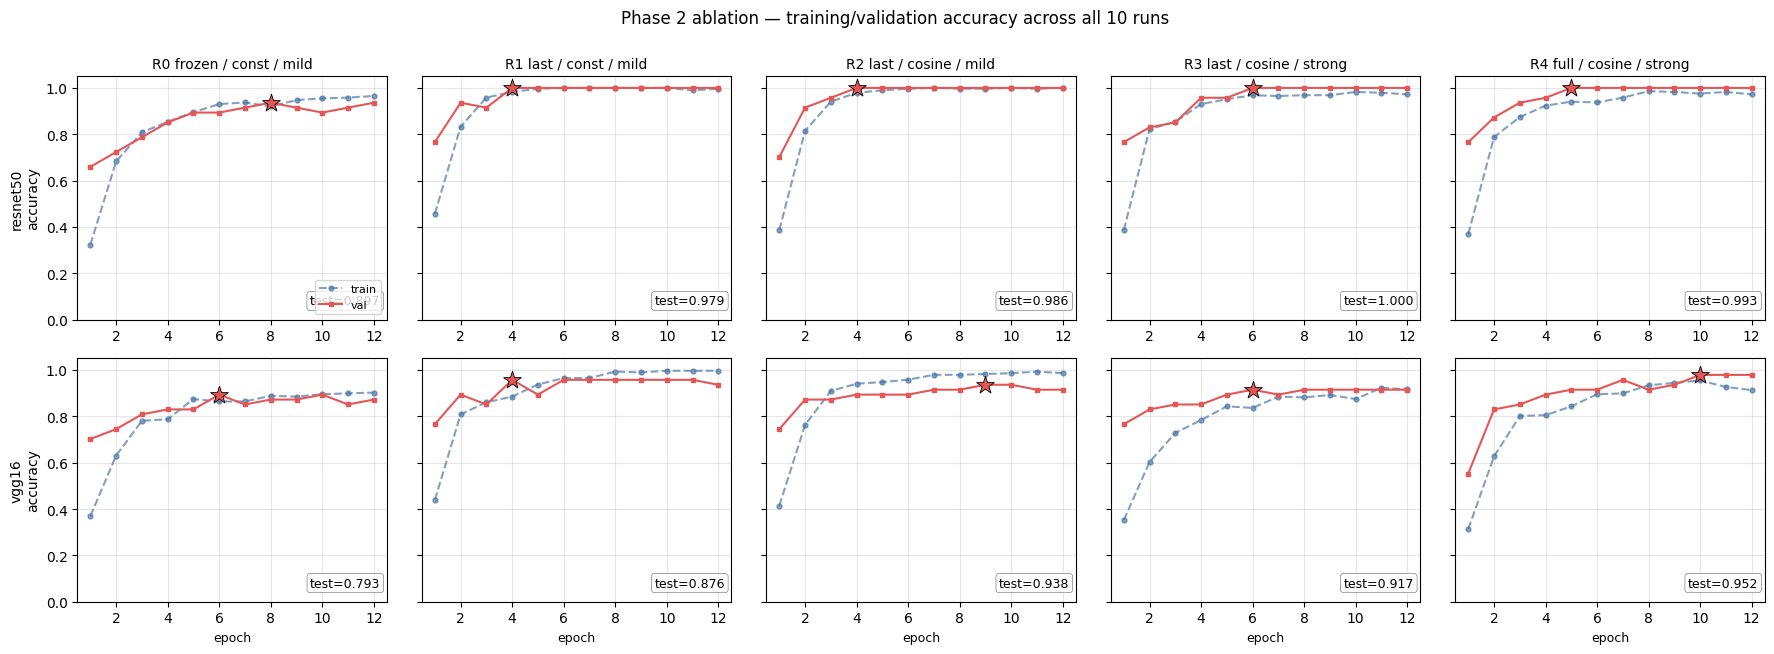

Saved: /content/drive/MyDrive/comp8430_project/outputs/figures_phase2/ablation_curves.png


In [ ]:
# ============================================================
# Training and validation curves for all 10 runs.
# Small multiples: 2 rows (resnet50, vgg16) x 5 columns (R0-R4).
# Each panel shows train acc (dashed) and val acc (solid).
# Useful for seeing: convergence speed, overfitting patterns,
# and where each run reaches its best val.
# ============================================================

run_order = ["R0_frozen_const_mild", "R1_last_const_mild",
             "R2_last_cosine_mild", "R3_last_cosine_strong",
             "R4_full_cosine_strong"]
arches    = ["resnet50", "vgg16"]
panel_titles = ["R0 frozen / const / mild",
                "R1 last / const / mild",
                "R2 last / cosine / mild",
                "R3 last / cosine / strong",
                "R4 full / cosine / strong"]

fig, axes = plt.subplots(2, 5, figsize=(18, 6.5), sharey=True)
for i, arch in enumerate(arches):
    for j, run_suffix in enumerate(run_order):
        run_id = f"{arch}_{run_suffix}"
        h = phase2_results[run_id]["history"]
        epochs = range(1, len(h["train_acc"]) + 1)
        ax = axes[i, j]
        ax.plot(epochs, h["train_acc"], linestyle="--", marker="o",
                markersize=3.5, color="#4C78A8", label="train", alpha=0.7)
        ax.plot(epochs, h["val_acc"],   linestyle="-",  marker="s",
                markersize=3.5, color="#E45756", label="val")
        # Mark the best-val epoch with a star
        best_ep = h["val_acc"].index(max(h["val_acc"])) + 1
        ax.scatter([best_ep], [max(h["val_acc"])], marker="*", s=180,
                   color="#E45756", edgecolor="black", linewidth=0.6, zorder=5)
        # Annotate with the test accuracy for this run
        test_acc = test_results[run_id]["test_acc"]
        ax.text(0.98, 0.05, f"test={test_acc:.3f}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", lw=0.5))
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0.5, len(h["train_acc"]) + 0.5)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title(panel_titles[j], fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{arch}\naccuracy", fontsize=10)
        if i == 1:
            ax.set_xlabel("epoch", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Phase 2 ablation — training/validation accuracy across all 10 runs",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'ablation_curves.png'}")

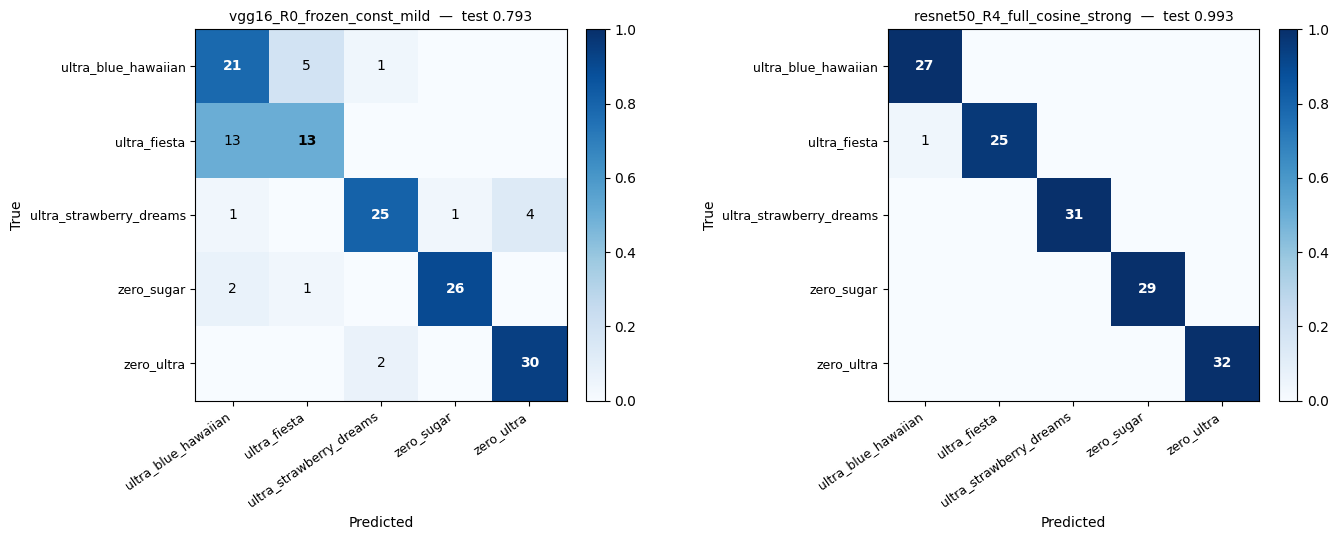


=== Confusion matrix — vgg16_R0_frozen_const_mild ===
true \ pred                        ultra_blue_haw  ultra_fiestaultra_strawber    zero_sugar    zero_ultra
ultra_blue_hawaiian                            21             5             1             0             0
ultra_fiesta                                   13            13             0             0             0
ultra_strawberry_dreams                         1             0            25             1             4
zero_sugar                                      2             1             0            26             0
zero_ultra                                      0             0             2             0            30

=== Confusion matrix — resnet50_R4_full_cosine_strong ===
true \ pred                        ultra_blue_haw  ultra_fiestaultra_strawber    zero_sugar    zero_ultra
ultra_blue_hawaiian                            27             0             0             0             0
ultra_fiesta                          

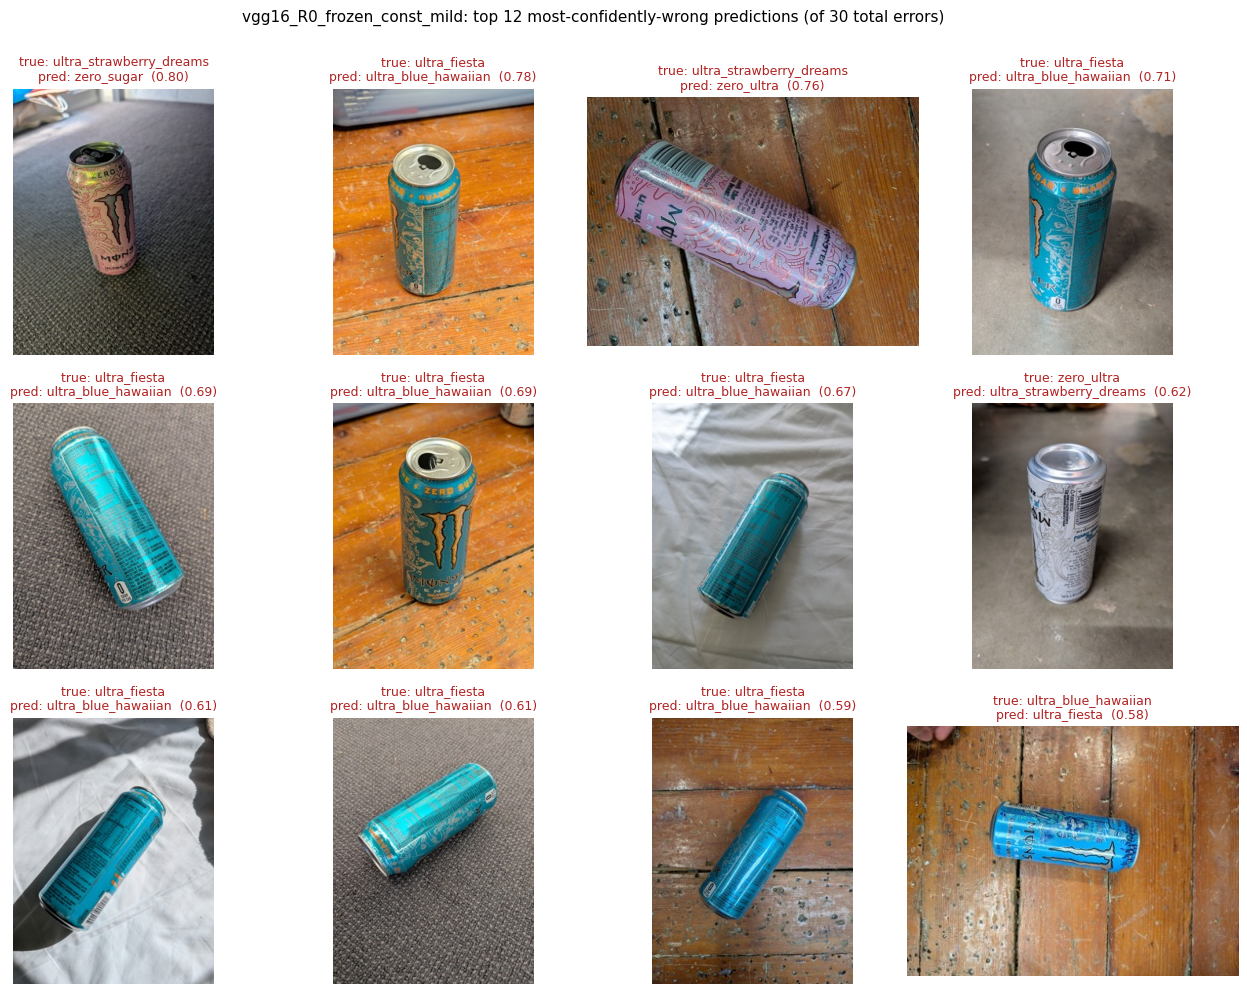

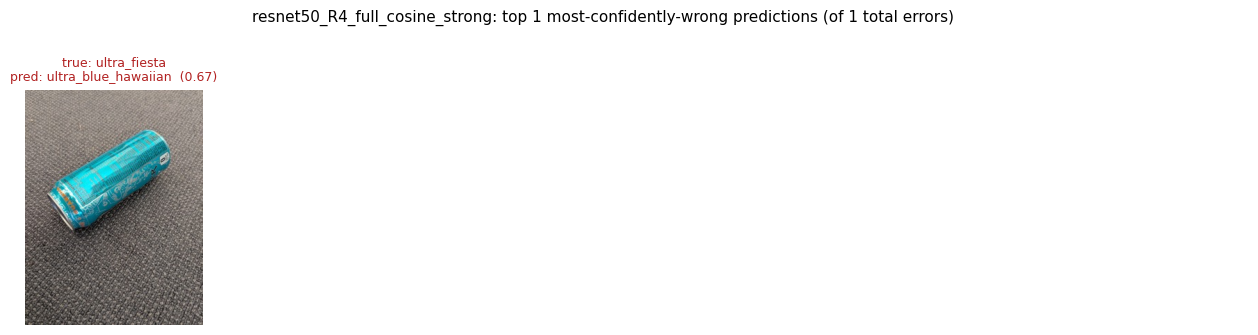

In [ ]:
# ============================================================
# Confusion matrices and misclassification grids for two runs:
#   - vgg16_R0_frozen_const_mild      (worst, 0.793)
#   - resnet50_R4_full_cosine_strong  (best informative, 0.993)
# (resnet50_R3 achieved 1.000 but has no errors to inspect, so
# it's mentioned in the report but not visualised here.)
# ============================================================

short_class = [c.replace("monster__", "") for c in CLASS_NAMES]

def confusion_matrix(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1
    return cm

def plot_cm(ax, run_id):
    tr = test_results[run_id]
    cm = confusion_matrix(tr["labels"], tr["preds"], NUM_CLASSES)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_class, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(short_class, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{run_id}  —  test {tr['test_acc']:.3f}", fontsize=10)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            cnt = cm[i, j]
            if cnt == 0: continue
            txt_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(cnt), ha="center", va="center",
                    color=txt_color, fontsize=10,
                    fontweight="bold" if i == j else "normal")
    return im

chosen = ["vgg16_R0_frozen_const_mild", "resnet50_R4_full_cosine_strong"]

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, run_id in zip(axes, chosen):
    im = plot_cm(ax, run_id)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Print confusion matrices as text for the report ---
for run_id in chosen:
    cm = confusion_matrix(test_results[run_id]["labels"],
                          test_results[run_id]["preds"], NUM_CLASSES)
    print(f"\n=== Confusion matrix \u2014 {run_id} ===")
    print(f"{'true \\ pred':<35s}" + "".join(f"{n[:14]:>14s}" for n in short_class))
    for i, cname in enumerate(short_class):
        row = f"{cname:<35s}" + "".join(f"{cm[i, j]:>14d}" for j in range(NUM_CLASSES))
        print(row)

# --- Misclassification grids ---
def misclass_grid(run_id, n=12):
    tr = test_results[run_id]
    labels, preds, probs = tr["labels"], tr["preds"], tr["probs"]
    wrong = np.where(labels != preds)[0]
    if len(wrong) == 0:
        print(f"{run_id}: no errors to show.")
        return
    # Sort by confidence in the wrong prediction (descending)
    pred_conf = probs[wrong, preds[wrong]]
    wrong = wrong[np.argsort(-pred_conf)]
    n = min(n, len(wrong))
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows))
    axes = np.array(axes).flatten()
    test_entries = split_doc["splits"]["test"]
    for ax, idx in zip(axes, wrong[:n]):
        rel_path, true_cname = test_entries[idx]
        img = Image.open(DATA_DIR / rel_path).convert("RGB")
        ax.imshow(img)
        true_short = true_cname.replace("monster__", "")
        pred_short = IDX_TO_CLASS[preds[idx]].replace("monster__", "")
        conf = probs[idx, preds[idx]]
        ax.set_title(f"true: {true_short}\npred: {pred_short}  ({conf:.2f})",
                     fontsize=9, color="firebrick")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.suptitle(f"{run_id}: top {n} most-confidently-wrong predictions "
                 f"(of {len(wrong)} total errors)", fontsize=11, y=1.00)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"phase2_misclass_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

for run_id in chosen:
    misclass_grid(run_id, n=12)

In [ ]:
# ============================================================
# Phase 2 summary: ablation results sorted by test accuracy,
# with Phase 1-2 baselines included for direct comparison.
# Also emits a markdown table suitable for pasting into the
# report draft if needed.
# ============================================================

# Phase 1-2 baselines for context (from the frozen feature extractor runs)
PHASE1_BASELINES = {"resnet50": 0.862, "vgg16": 0.834}

rows = []
# Phase 1-2 baselines as their own rows for direct comparison
for arch, acc in PHASE1_BASELINES.items():
    rows.append({
        "run":      f"{arch}  (Phase 1-2 baseline)",
        "strategy": "frozen", "schedule": "constant", "aug": "mild",
        "val_acc":  None, "test_acc": acc, "trainable_pct": 0.04 if arch == "resnet50" else 0.02,
        "best_epoch": None, "is_baseline": True,
    })
# All Phase 2 runs
for run_id, m in test_results.items():
    info = phase2_results[run_id]["info"]
    h = phase2_results[run_id]["history"]
    rows.append({
        "run":      run_id,
        "strategy": m["config"]["strategy"],
        "schedule": m["config"]["schedule"],
        "aug":      m["config"]["aug"],
        "val_acc":  m["best_val_acc"],
        "test_acc": m["test_acc"],
        "trainable_pct": info["trainable_fraction"] * 100,
        "best_epoch": h["val_acc"].index(max(h["val_acc"])) + 1,
        "is_baseline": False,
    })

# Sort by test accuracy, but keep the two baselines at the top of their respective architecture blocks
rows.sort(key=lambda r: (-r["test_acc"]))

# Pretty-print
print(f"{'Run':<42s} {'Strat':<11s} {'Sched':<8s} {'Aug':<7s} "
      f"{'Train%':>7s} {'BestEp':>7s} {'ValAcc':>7s} {'TestAcc':>8s}")
print("-" * 102)
for r in rows:
    val_s = f"{r['val_acc']:>7.4f}" if r["val_acc"] is not None else f"{'-':>7s}"
    bestep_s = f"{r['best_epoch']:>7d}" if r["best_epoch"] is not None else f"{'-':>7s}"
    marker = "  <- baseline" if r["is_baseline"] else ""
    print(f"{r['run']:<42s} {r['strategy']:<11s} {r['schedule']:<8s} {r['aug']:<7s} "
          f"{r['trainable_pct']:>6.2f}% {bestep_s} {val_s} {r['test_acc']:>8.4f}"
          f"{marker}")

# --- Architecture-level "best per arch" summary ---
print("\nBest configuration per architecture (excluding leakage-suspected 1.0000 run):")
best_per_arch = {}
for r in rows:
    if r["is_baseline"]:
        continue
    arch = "resnet50" if r["run"].startswith("resnet50") else "vgg16"
    # Exclude the perfect-score run from "best" because we don't trust it as a measurement
    if r["test_acc"] >= 0.9999:
        continue
    if arch not in best_per_arch or r["test_acc"] > best_per_arch[arch]["test_acc"]:
        best_per_arch[arch] = r

for arch, r in best_per_arch.items():
    base = PHASE1_BASELINES[arch]
    print(f"  {arch:<10s}  best informative run: {r['run']}  test={r['test_acc']:.4f}  "
          f"({(r['test_acc']-base)*100:+.1f}pp vs Phase 1-2 baseline {base:.3f})")

# Save the summary
with open(LOG_DIR / "phase2_summary.json", "w") as f:
    json.dump(rows, f, indent=2)
print(f"\nSaved: {LOG_DIR / 'phase2_summary.json'}")

Run                                        Strat       Sched    Aug      Train%  BestEp  ValAcc  TestAcc
------------------------------------------------------------------------------------------------------
resnet50_R3_last_cosine_strong             last_block  cosine   strong   63.67%       6  1.0000   1.0000
resnet50_R4_full_cosine_strong             full        cosine   strong  100.00%       5  1.0000   0.9931
resnet50_R2_last_cosine_mild               last_block  cosine   mild     63.67%       4  1.0000   0.9862
resnet50_R1_last_const_mild                last_block  constant mild     63.67%       4  1.0000   0.9793
vgg16_R4_full_cosine_strong                full        cosine   strong  100.00%      10  0.9787   0.9517
vgg16_R2_last_cosine_mild                  last_block  cosine   mild      5.29%       9  0.9362   0.9379
vgg16_R3_last_cosine_strong                last_block  cosine   strong    5.29%       6  0.9149   0.9172
resnet50_R0_frozen_const_mild              frozen      co

### Fine Tuning on all classes
Fine tuning VGG16 and ResNet50 models with the photos taken of all beverage drink cans

In [ ]:
# ============================================================
# Inventory the now-extended dataset (19 classes).
# Monster classes already have ~85-105 images from Phase 1-2;
# Coke / Red Bull / V classes have ~30 each from the new collection.
# This cell just sanity-checks the directory and prints counts.
# ============================================================

# Re-scan DATA_DIR (which now contains all 19 classes)
class_dirs_all = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Found {len(class_dirs_all)} class folders in {DATA_DIR}:\n")

counts_all = {}
for d in class_dirs_all:
    imgs = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS]
    counts_all[d.name] = len(imgs)

# Group by brand for readable output
by_brand = {}
for cname, n in counts_all.items():
    brand = cname.split("__")[0]
    by_brand.setdefault(brand, []).append((cname, n))

for brand, items in by_brand.items():
    brand_total = sum(n for _, n in items)
    print(f"  [{brand}] ({len(items)} classes, {brand_total} images)")
    for cname, n in items:
        print(f"    {cname:<45s} {n:>4d}")
    print()

total = sum(counts_all.values())
mins, maxs = min(counts_all.values()), max(counts_all.values())
print(f"Total: {total} images across {len(class_dirs_all)} classes")
print(f"Min/max per class: {mins} / {maxs}  (imbalance ratio {maxs/mins:.2f}x)")

Found 19 class folders in /content/drive/MyDrive/comp8430_project/data/resized_256:

  [cocacola] (4 classes, 301 images)
    cocacola__classic                               73
    cocacola__diet                                  70
    cocacola__vanilla                               78
    cocacola__zero                                  80

  [monster] (5 classes, 479 images)
    monster__ultra_blue_hawaiian                    91
    monster__ultra_fiesta                           84
    monster__ultra_strawberry_dreams               102
    monster__zero_sugar                             98
    monster__zero_ultra                            104

  [redbull] (5 classes, 379 images)
    redbull__berry                                  77
    redbull__classic                                86
    redbull__red                                    68
    redbull__sugar_free                             72
    redbull__tropical                               76

  [v] (5 classes, 353 images)
   

In [ ]:
# ============================================================
# Stratified 60/10/30 split for the 19-class dataset.
# Same protocol as Phase 1-2: per-class shuffle, fixed seed,
# remainder absorbed by test, paths stored relative to DATA_DIR.
# Saved to a NEW file (splits_all.json) so the original Monster
# splits file stays untouched.
# ============================================================

SPLITS_ALL_FILE = LOG_DIR / "splits_all.json"
TRAIN_FRAC, VAL_FRAC = 0.60, 0.10   # test = remainder

# Gather (relative path, class) pairs grouped by class
by_class_all = {}
for cdir in class_dirs_all:
    files = sorted([f.relative_to(DATA_DIR).as_posix()
                    for f in cdir.iterdir()
                    if f.suffix.lower() in IMG_EXTS])
    by_class_all[cdir.name] = files

rng = random.Random(SEED)  # independent RNG state, reproducible

splits_all = {"train": [], "val": [], "test": []}
split_summary = {}

for cname in sorted(by_class_all.keys()):
    files = by_class_all[cname][:]
    rng.shuffle(files)
    n = len(files)
    n_train = int(round(n * TRAIN_FRAC))
    n_val   = int(round(n * VAL_FRAC))
    n_test  = n - n_train - n_val
    splits_all["train"].extend((f, cname) for f in files[:n_train])
    splits_all["val"].extend((f, cname)   for f in files[n_train:n_train + n_val])
    splits_all["test"].extend((f, cname)  for f in files[n_train + n_val:])
    split_summary[cname] = {"total": n, "train": n_train, "val": n_val, "test": n_test}

with open(SPLITS_ALL_FILE, "w") as f:
    json.dump({
        "seed": SEED,
        "fractions": {"train": TRAIN_FRAC, "val": VAL_FRAC, "test": 1 - TRAIN_FRAC - VAL_FRAC},
        "data_dir": str(DATA_DIR),
        "splits": {k: [list(t) for t in v] for k, v in splits_all.items()},
    }, f, indent=2)

# Pretty-print summary
print(f"{'class':<45s} {'total':>6s} {'train':>6s} {'val':>5s} {'test':>5s}")
print("-" * 70)
for cname in sorted(split_summary.keys()):
    s = split_summary[cname]
    print(f"{cname:<45s} {s['total']:>6d} {s['train']:>6d} {s['val']:>5d} {s['test']:>5d}")
print("-" * 70)
totals = {k: sum(s[k] for s in split_summary.values()) for k in ["total", "train", "val", "test"]}
print(f"{'TOTAL':<45s} {totals['total']:>6d} {totals['train']:>6d} {totals['val']:>5d} {totals['test']:>5d}")
print(f"\nSaved: {SPLITS_ALL_FILE}")

class                                          total  train   val  test
----------------------------------------------------------------------
cocacola__classic                                 73     44     7    22
cocacola__diet                                    70     42     7    21
cocacola__vanilla                                 78     47     8    23
cocacola__zero                                    80     48     8    24
monster__ultra_blue_hawaiian                      91     55     9    27
monster__ultra_fiesta                             84     50     8    26
monster__ultra_strawberry_dreams                 102     61    10    31
monster__zero_sugar                               98     59    10    29
monster__zero_ultra                              104     62    10    32
redbull__berry                                    77     46     8    23
redbull__classic                                  86     52     9    25
redbull__red                                      68     41     7

In [ ]:
# ============================================================
# Rebuild dataset objects and DataLoaders for the 19-class problem.
# ============================================================

with open(SPLITS_ALL_FILE) as f:
    split_doc_all = json.load(f)

# 19-class index, alphabetically sorted for stability
CLASS_NAMES_ALL  = sorted(by_class_all.keys())
CLASS_TO_IDX_ALL = {c: i for i, c in enumerate(CLASS_NAMES_ALL)}
IDX_TO_CLASS_ALL = {i: c for c, i in CLASS_TO_IDX_ALL.items()}
NUM_CLASSES_ALL  = len(CLASS_NAMES_ALL)

# Datasets
train_ds_mild_all   = CansDataset(DATA_DIR, split_doc_all["splits"]["train"], CLASS_TO_IDX_ALL, tf_mild)
train_ds_strong_all = CansDataset(DATA_DIR, split_doc_all["splits"]["train"], CLASS_TO_IDX_ALL, tf_strong)
val_ds_all          = CansDataset(DATA_DIR, split_doc_all["splits"]["val"],   CLASS_TO_IDX_ALL, tf_eval)
test_ds_all         = CansDataset(DATA_DIR, split_doc_all["splits"]["test"],  CLASS_TO_IDX_ALL, tf_eval)

# DataLoaders (same batch size and workers as Phase 2 Monster-only)
train_loader_mild_all   = DataLoader(train_ds_mild_all,   batch_size=BATCH_SIZE, shuffle=True,
                                     num_workers=NUM_WORKERS, pin_memory=True)
train_loader_strong_all = DataLoader(train_ds_strong_all, batch_size=BATCH_SIZE, shuffle=True,
                                     num_workers=NUM_WORKERS, pin_memory=True)
val_loader_all   = DataLoader(val_ds_all,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
test_loader_all  = DataLoader(test_ds_all,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

print(f"Classes ({NUM_CLASSES_ALL}):")
for i, c in enumerate(CLASS_NAMES_ALL):
    print(f"  {i:>2d}  {c}")
print()
print(f"Train (mild):   {len(train_ds_mild_all):4d}  ({len(train_loader_mild_all)} batches)")
print(f"Train (strong): {len(train_ds_strong_all):4d}  ({len(train_loader_strong_all)} batches)")
print(f"Val:            {len(val_ds_all):4d}  ({len(val_loader_all)} batches)")
print(f"Test:           {len(test_ds_all):4d}  ({len(test_loader_all)} batches)")

Classes (19):
   0  cocacola__classic
   1  cocacola__diet
   2  cocacola__vanilla
   3  cocacola__zero
   4  monster__ultra_blue_hawaiian
   5  monster__ultra_fiesta
   6  monster__ultra_strawberry_dreams
   7  monster__zero_sugar
   8  monster__zero_ultra
   9  redbull__berry
  10  redbull__classic
  11  redbull__red
  12  redbull__sugar_free
  13  redbull__tropical
  14  v__blue
  15  v__raspberry_lemonade
  16  v__refresh
  17  v__strawberries_cream
  18  v__zero_sugar

Train (mild):    908  (29 batches)
Train (strong):  908  (29 batches)
Val:             150  (5 batches)
Test:            454  (15 batches)


In [ ]:
# ============================================================
# Re-run the 5-configuration ablation on the full 19-class
# dataset, for both ResNet-50 and VGG-16 (10 runs total).
#
# Identical hyperparameters, transforms, and run_finetuning
# ============================================================

# Same grid definition as the Monster run
GRID_ALL = [
    ("R0_frozen_const_mild",  "frozen",     "constant", "mild"),
    ("R1_last_const_mild",    "last_block", "constant", "mild"),
    ("R2_last_cosine_mild",   "last_block", "cosine",   "mild"),
    ("R3_last_cosine_strong", "last_block", "cosine",   "strong"),
    ("R4_full_cosine_strong", "full",       "cosine",   "strong"),
]

EPOCHS_ALL = 12

# Save the Monster-only references
_orig = {
    "val_loader":  val_loader,
    "NUM_CLASSES": NUM_CLASSES,
    "CLASS_TO_IDX": CLASS_TO_IDX,
}

# Swap to 19-class references
val_loader   = val_loader_all
NUM_CLASSES  = NUM_CLASSES_ALL
CLASS_TO_IDX = CLASS_TO_IDX_ALL

phase2_all_results = {}

t_grid_start = time.time()
for arch in ["resnet50", "vgg16"]:
    for suffix, strategy, schedule, aug in GRID_ALL:
        run_id = f"{arch}_{suffix}_all"
        loader = train_loader_strong_all if aug == "strong" else train_loader_mild_all

        model, history, info = run_finetuning(
            model_name=arch,
            strategy=strategy,
            train_loader=loader,
            num_epochs=EPOCHS_ALL,
            head_lr=1e-3,
            backbone_lr=1e-4,
            schedule=schedule,
            weight_decay=1e-4,
            run_id=run_id,
            verbose=True,
        )
        phase2_all_results[run_id] = {
            "model": model,
            "history": history,
            "info": info,
            "config": {"arch": arch, "strategy": strategy,
                       "schedule": schedule, "aug": aug},
        }
        torch.cuda.empty_cache()

# Restore Monster-only references so re-running earlier cells still works
val_loader   = _orig["val_loader"]
NUM_CLASSES  = _orig["NUM_CLASSES"]
CLASS_TO_IDX = _orig["CLASS_TO_IDX"]

print(f"\n=== 19-class grid complete in {(time.time()-t_grid_start)/60:.1f} min ===")
print(f"Trained {len(phase2_all_results)} models, saved to {MODEL_DIR}")


=== resnet50_R0_frozen_const_mild_all | resnet50 | strategy=frozen | schedule=constant | epochs=12 ===
 Ep  tr_loss  tr_acc  va_loss  va_acc   time lrs
  1   2.6697  0.2753   2.3297  0.6067  48.9s * [1e-03]
  2   2.0575  0.6762   1.8609  0.7200   5.8s * [1e-03]
  3   1.6022  0.8425   1.5540  0.8000   5.7s * [1e-03]
  4   1.3169  0.8855   1.2977  0.8667   5.8s * [1e-03]
  5   1.0769  0.9240   1.1110  0.8867   5.9s * [1e-03]
  6   0.8918  0.9416   0.9552  0.9000   5.7s * [1e-03]
  7   0.7843  0.9482   0.8485  0.9133   5.7s * [1e-03]
  8   0.6657  0.9703   0.7741  0.9200   5.7s * [1e-03]
  9   0.5932  0.9758   0.7152  0.9267   5.9s * [1e-03]
 10   0.5339  0.9769   0.6322  0.9333   5.8s * [1e-03]
 11   0.4629  0.9835   0.5604  0.9200   6.0s   [1e-03]
 12   0.4113  0.9901   0.5306  0.9467   5.7s * [1e-03]
  best val_acc = 0.9467 at epoch 12
  saved: resnet50_R0_frozen_const_mild_all.pt

=== resnet50_R1_last_const_mild_all | resnet50 | strategy=last_block | schedule=constant | epochs=12 ===

In [ ]:
# ============================================================
# Test-set evaluation for the 10 runs on the 19-class problem.
# Stores per-run predictions and metrics in test_results_all.
# ============================================================

test_results_all = {}
for run_id, r in phase2_all_results.items():
    labels, preds, probs = predict_all(r["model"], test_loader_all)
    acc = (labels == preds).mean()
    test_loss = -np.log(np.clip(probs[np.arange(len(labels)), labels], 1e-12, 1.0)).mean()
    per_class = per_class_accuracy(labels, preds, NUM_CLASSES_ALL)
    m_f1 = macro_f1(labels, preds, NUM_CLASSES_ALL)
    best_val = max(r["history"]["val_acc"])
    test_results_all[run_id] = {
        "labels": labels, "preds": preds, "probs": probs,
        "test_acc": float(acc), "test_loss": float(test_loss),
        "macro_f1": float(m_f1), "per_class_acc": per_class.tolist(),
        "best_val_acc": float(best_val),
        "config": r["config"],
    }

# --- Headline ranking ---
rows = sorted(test_results_all.items(), key=lambda kv: -kv[1]["test_acc"])
print(f"{'Run':<45s} {'Val':>7s} {'Test':>7s} {'TestLoss':>9s} {'MacroF1':>8s}")
print("-" * 80)
for run_id, m in rows:
    print(f"{run_id:<45s} {m['best_val_acc']:>7.4f} {m['test_acc']:>7.4f} "
          f"{m['test_loss']:>9.4f} {m['macro_f1']:>8.4f}")

# --- Per-brand average accuracy ---
print("\n\nPer-brand average test accuracy (across the classes in each brand):")
brands = ["cocacola", "monster", "redbull", "v"]
brand_indices = {b: [i for i, c in enumerate(CLASS_NAMES_ALL) if c.startswith(b + "__")]
                 for b in brands}

print(f"{'Run':<45s} " + " ".join(f"{b:>10s}" for b in brands) + f" {'overall':>10s}")
print("-" * (47 + 11 * (len(brands) + 1)))
for run_id, m in rows:
    pca = m["per_class_acc"]
    brand_avg = {b: np.mean([pca[i] for i in brand_indices[b]]) for b in brands}
    row = f"{run_id:<45s} " + " ".join(f"{brand_avg[b]:>10.4f}" for b in brands)
    row += f" {m['test_acc']:>10.4f}"
    print(row)

# Persist metrics (without big numpy arrays)
metrics_summary = {
    rid: {k: v for k, v in m.items() if k not in ("labels", "preds", "probs")}
    for rid, m in test_results_all.items()
}
with open(LOG_DIR / "phase2_all_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
print(f"\nSaved: {LOG_DIR / 'phase2_all_metrics.json'}")

Run                                               Val    Test  TestLoss  MacroF1
--------------------------------------------------------------------------------
resnet50_R1_last_const_mild_all                0.9800  0.9934    0.0359   0.9932
resnet50_R3_last_cosine_strong_all             0.9933  0.9868    0.0326   0.9868
resnet50_R4_full_cosine_strong_all             0.9933  0.9868    0.0373   0.9870
resnet50_R2_last_cosine_mild_all               0.9733  0.9846    0.0553   0.9848
vgg16_R1_last_const_mild_all                   0.9667  0.9559    0.1319   0.9564
vgg16_R2_last_cosine_mild_all                  0.9667  0.9559    0.1008   0.9555
vgg16_R4_full_cosine_strong_all                0.9733  0.9537    0.1337   0.9542
resnet50_R0_frozen_const_mild_all              0.9467  0.9493    0.5266   0.9498
vgg16_R3_last_cosine_strong_all                0.9467  0.9427    0.1481   0.9435
vgg16_R0_frozen_const_mild_all                 0.8133  0.8436    0.5574   0.8457


Per-brand average test acc

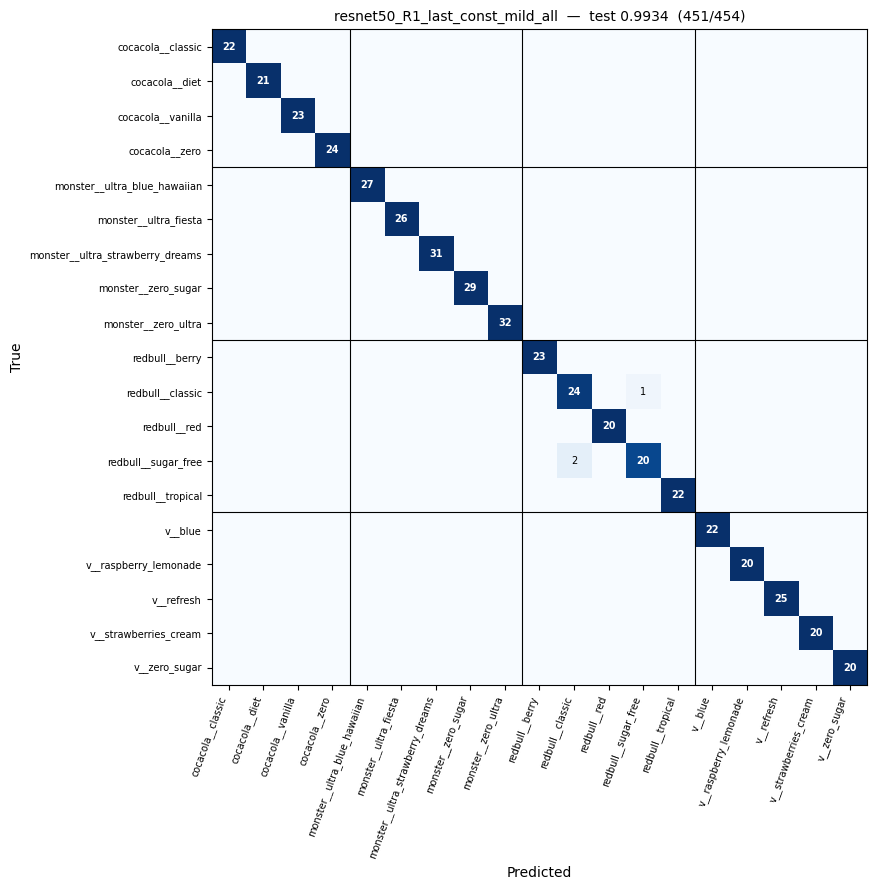

Red Bull test images: 112 of 454


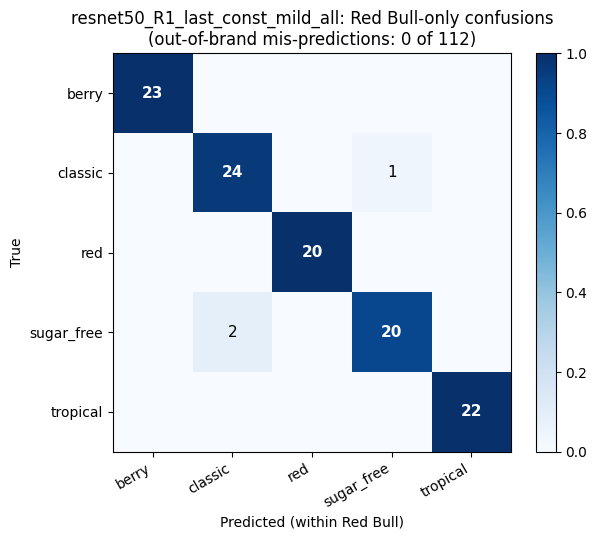


=== All 3 errors for resnet50_R1_last_const_mild_all ===
  true: redbull__classic                         -> pred: redbull__sugar_free                       (conf=0.985)
  true: redbull__sugar_free                      -> pred: redbull__classic                          (conf=0.669)
  true: redbull__sugar_free                      -> pred: redbull__classic                          (conf=0.913)


In [ ]:
# ============================================================
# Confusion matrices for the 19-class problem.
# - Full 19x19 matrix for ResNet R3 (top informative result).
# - Brand-grouped block view: per-brand block accuracy and
#   per-brand confusion structure are more readable than the
#   raw 19x19 matrix.
# ============================================================

short_names_all = CLASS_NAMES_ALL

def confusion_matrix_19(labels, preds, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(labels, preds): cm[t, p] += 1
    return cm

# Pick the headline model
top_run = "resnet50_R1_last_const_mild_all"
tr = test_results_all[top_run]
cm_full = confusion_matrix_19(tr["labels"], tr["preds"], NUM_CLASSES_ALL)

# --- Full 19x19 matrix ---
fig, ax = plt.subplots(figsize=(11, 9))
cm_norm = cm_full / np.maximum(cm_full.sum(axis=1, keepdims=True), 1)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES_ALL))
ax.set_yticks(range(NUM_CLASSES_ALL))
ax.set_xticklabels(short_names_all, rotation=70, ha="right", fontsize=7)
ax.set_yticklabels(short_names_all, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"{top_run}  —  test {tr['test_acc']:.4f}  ({(tr['labels']==tr['preds']).sum()}/{len(tr['labels'])})",
             fontsize=10)
for i in range(NUM_CLASSES_ALL):
    for j in range(NUM_CLASSES_ALL):
        cnt = cm_full[i, j]
        if cnt == 0: continue
        txt_color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, str(cnt), ha="center", va="center",
                color=txt_color, fontsize=7,
                fontweight="bold" if i == j else "normal")
# Brand-group separator lines for readability
brand_boundaries = []
cur_brand = None
for idx, c in enumerate(CLASS_NAMES_ALL):
    b = c.split("__")[0]
    if b != cur_brand and idx > 0:
        brand_boundaries.append(idx)
    cur_brand = b
for b in brand_boundaries:
    ax.axhline(b - 0.5, color="black", linewidth=0.8)
    ax.axvline(b - 0.5, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_all_confusion_resnet50_R3.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Red Bull-only 5x5 matrix ---
rb_indices = [i for i, c in enumerate(CLASS_NAMES_ALL) if c.startswith("redbull__")]
rb_names   = [CLASS_NAMES_ALL[i].replace("redbull__", "") for i in rb_indices]

# Build a Red Bull-only confusion matrix:
rb_mask = np.isin(tr["labels"], rb_indices)
print(f"Red Bull test images: {rb_mask.sum()} of {len(tr['labels'])}")

# this 5x5 view, with "predicted non-Red-Bull" counted separately).
idx_to_rbpos = {i: pos for pos, i in enumerate(rb_indices)}
rb_cm = np.zeros((5, 5), dtype=int)
rb_leak = np.zeros(5, dtype=int)  # true RB images predicted as non-RB
for t, p in zip(tr["labels"][rb_mask], tr["preds"][rb_mask]):
    rb_t = idx_to_rbpos[t]
    if p in rb_indices:
        rb_cm[rb_t, idx_to_rbpos[p]] += 1
    else:
        rb_leak[rb_t] += 1

fig2, ax2 = plt.subplots(figsize=(7, 5.5))
rb_cm_norm = rb_cm / np.maximum(rb_cm.sum(axis=1, keepdims=True) + rb_leak[:, None], 1)
im2 = ax2.imshow(rb_cm_norm, cmap="Blues", vmin=0, vmax=1)
ax2.set_xticks(range(5)); ax2.set_yticks(range(5))
ax2.set_xticklabels(rb_names, rotation=30, ha="right")
ax2.set_yticklabels(rb_names)
ax2.set_xlabel("Predicted (within Red Bull)")
ax2.set_ylabel("True")
ax2.set_title(f"{top_run}: Red Bull-only confusions\n"
              f"(out-of-brand mis-predictions: {rb_leak.sum()} of {rb_mask.sum()})")
for i in range(5):
    for j in range(5):
        if rb_cm[i, j] > 0:
            txt_color = "white" if rb_cm_norm[i, j] > 0.5 else "black"
            ax2.text(j, i, str(rb_cm[i, j]), ha="center", va="center",
                     color=txt_color, fontsize=11,
                     fontweight="bold" if i == j else "normal")
fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_all_redbull_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Text print of where the 7 errors actually are ---
print(f"\n=== All {len(tr['labels']) - (tr['labels']==tr['preds']).sum()} errors for {top_run} ===")
errors = np.where(tr["labels"] != tr["preds"])[0]
for idx in errors:
    true_c = IDX_TO_CLASS_ALL[tr["labels"][idx]]
    pred_c = IDX_TO_CLASS_ALL[tr["preds"][idx]]
    conf = tr["probs"][idx, tr["preds"][idx]]
    print(f"  true: {true_c:<40s} -> pred: {pred_c:<40s}  (conf={conf:.3f})")

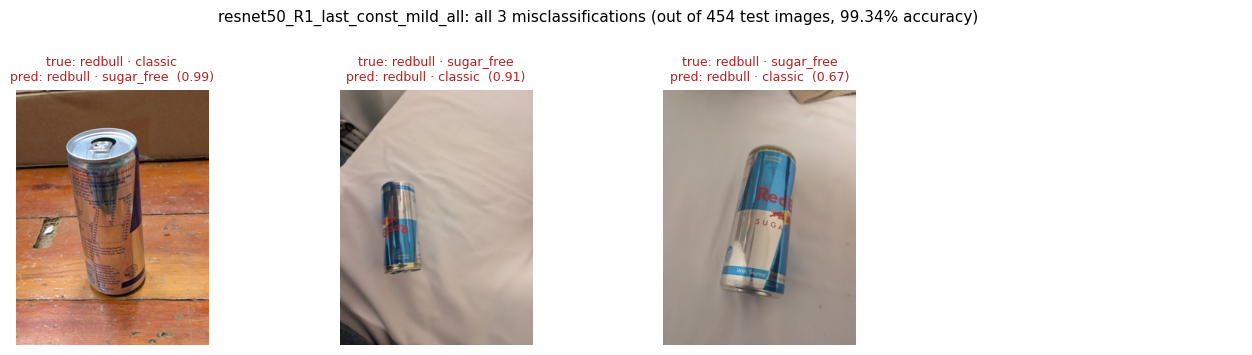

Saved: /content/drive/MyDrive/comp8430_project/outputs/figures_phase2/phase2_all_misclass_resnet50_R1_last_const_mild_all.png


In [ ]:
# ============================================================
# Misclassification grid: all errors from the 19-class
# ============================================================

top_run = "resnet50_R1_last_const_mild_all"
tr = test_results_all[top_run]

labels, preds, probs = tr["labels"], tr["preds"], tr["probs"]
wrong = np.where(labels != preds)[0]

# Sort by confidence in wrong prediction (descending = most-confident first).
pred_conf = probs[wrong, preds[wrong]]
wrong = wrong[np.argsort(-pred_conf)]

n = len(wrong)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()

test_entries = split_doc_all["splits"]["test"]

for ax, idx in zip(axes, wrong):
    rel_path, true_cname = test_entries[idx]
    img = Image.open(DATA_DIR / rel_path).convert("RGB")
    ax.imshow(img)
    true_short = true_cname.replace("__", " · ")     # readable brand · variant
    pred_short = IDX_TO_CLASS_ALL[preds[idx]].replace("__", " · ")
    conf = probs[idx, preds[idx]]
    ax.set_title(f"true: {true_short}\npred: {pred_short}  ({conf:.2f})",
                 fontsize=9, color="firebrick")
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle(f"{top_run}: all {n} misclassifications "
             f"(out of {len(labels)} test images, {tr['test_acc']*100:.2f}% accuracy)",
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / f"phase2_all_misclass_{top_run}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / f'phase2_all_misclass_{top_run}.png'}")